#  Sales Forecasting Project Overview

**This project aims to predict future sales using historical data. By analyzing past sales patterns, we can estimate how much a business is likely to sell in the future.**

Sales forecasting is important because it helps businesses:
- Plan how much stock to keep
- Avoid running out of products
- Reduce unnecessary costs
- Prepare staff for busy periods

The goal is not only to build a prediction model, but also to understand patterns in the data and present results in a clear, business-friendly way.

## 📂 Loading the Data

In this step, we load the dataset into Python so we can work with it.

The dataset contains historical sales records, including:
- Order dates
- Sales values
- Product and customer details

We also convert the "Order Date" column into a proper date format so that we can analyze how sales change over time.

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

In [22]:
df = pd.read_csv("train.csv")

# Convert date (FIX for your dataset)
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)

# Sort by date
df = df.sort_values('Order Date')

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
7980,7981,CA-2015-103800,2015-01-03,07/01/2015,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,Texas,77095.0,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448
741,742,CA-2015-112326,2015-01-04,08/01/2015,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540.0,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540
740,741,CA-2015-112326,2015-01-04,08/01/2015,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540.0,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736
739,740,CA-2015-112326,2015-01-04,08/01/2015,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540.0,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784
1759,1760,CA-2015-141817,2015-01-05,12/01/2015,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,Pennsylvania,19143.0,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536


In [23]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 9800 entries, 7980 to 5091
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   object        
 2   Order Date     9800 non-null   datetime64[ns]
 3   Ship Date      9800 non-null   object        
 4   Ship Mode      9800 non-null   object        
 5   Customer ID    9800 non-null   object        
 6   Customer Name  9800 non-null   object        
 7   Segment        9800 non-null   object        
 8   Country        9800 non-null   object        
 9   City           9800 non-null   object        
 10  State          9800 non-null   object        
 11  Postal Code    9789 non-null   float64       
 12  Region         9800 non-null   object        
 13  Product ID     9800 non-null   object        
 14  Category       9800 non-null   object        
 15  Sub-Category   9800 non

,Row ID,Order Date,Postal Code,Sales
count,9800.000000,9800,9789.000000,9800.000000
mean,4900.500000,2017-05-01 05:13:51.673469440,55273.322403,230.769059
min,1.000000,2015-01-03 00:00:00,1040.000000,0.444000
25%,2450.750000,2016-05-24 00:00:00,23223.000000,17.248000
50%,4900.500000,2017-06-26 00:00:00,58103.000000,54.490000
75%,7350.250000,2018-05-15 00:00:00,90008.000000,210.605000
max,9800.000000,2018-12-30 00:00:00,99301.000000,22638.480000
std,2829.160653,NaN,32041.223413,626.651875


## Data Cleaning

Before analyzing the data, we need to make sure it is clean and usable.

This includes:
- Checking for missing values
- Removing incomplete records
- Ensuring all data types are correct

Clean data is important because incorrect or missing values can lead to inaccurate predictions.

In [24]:
# Check missing values
df.isnull().sum()

# Drop missing values (simple approach)
df = df.dropna()

##  Aggregating Sales Data

The original dataset contains individual transactions. However, for forecasting, we need to understand how total sales change over time.

We group the data by date and calculate the total sales for each day.

This transforms the data into a time series format, which is required for forecasting.

In [25]:
# Convert to daily sales
daily_sales = df.groupby('Order Date')['Sales'].sum().reset_index()

daily_sales.head()

,Order Date,Sales
0,2015-01-03,16.448
1,2015-01-04,288.060
2,2015-01-05,19.536
3,2015-01-06,4407.100
4,2015-01-07,87.158


##  Visualizing Sales Trends

We plot sales over time to observe patterns.

This helps us identify:
- Trends (e.g., increasing or decreasing sales)
- Seasonality (repeating patterns over time)
- Unusual spikes or drops

Understanding these patterns is important before building a model.

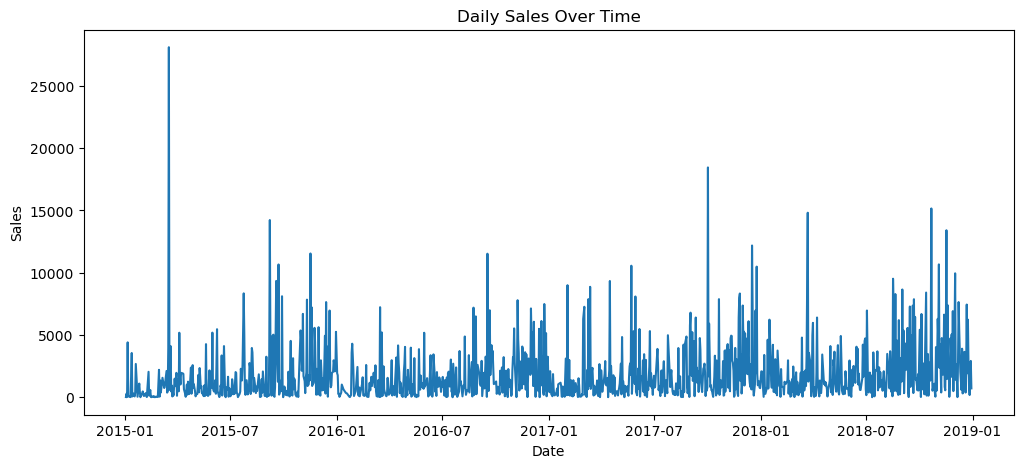

In [26]:
plt.figure(figsize=(12,5))
plt.plot(daily_sales['Order Date'], daily_sales['Sales'])
plt.title("Daily Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

## Creating Time-Based Features

To help the model understand patterns in time, we extract additional information from the date, such as:
- Year
- Month
- Day
- Day of the week

We also create a feature to indicate whether a day is a weekend.

These features help the model learn how sales change depending on time.

In [27]:
daily_sales['Year'] = daily_sales['Order Date'].dt.year
daily_sales['Month'] = daily_sales['Order Date'].dt.month
daily_sales['Day'] = daily_sales['Order Date'].dt.day
daily_sales['DayOfWeek'] = daily_sales['Order Date'].dt.dayofweek

# Weekend feature
daily_sales['IsWeekend'] = daily_sales['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)

daily_sales.head()

,Order Date,Sales,Year,Month,Day,DayOfWeek,IsWeekend
0,2015-01-03,16.448,2015,1,3,5,1
1,2015-01-04,288.060,2015,1,4,6,1
2,2015-01-05,19.536,2015,1,5,0,0
3,2015-01-06,4407.100,2015,1,6,1,0
4,2015-01-07,87.158,2015,1,7,2,0


## Evaluating the Model

To measure how well the model performs, we calculate the Mean Absolute Error (MAE).

MAE tells us the average difference between the predicted sales and the actual sales.

A lower MAE means the model is making more accurate predictions.

In [43]:
X = daily_sales[['Year', 'Month', 'Day', 'DayOfWeek', 'IsWeekend']]
y = daily_sales['Sales']

# Train-test split (NO shuffle for time series)
X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=False)

##  Comparing Actual vs Predicted Sales

We visualize both the actual sales and the predicted sales on a graph.

This helps us see how closely the model's predictions match real data.

A good model will produce predictions that closely follow the actual sales trend.

In [30]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


##  Forecasting Future Sales

Using the trained model, we predict sales for future dates.

This allows us to estimate demand for the next 30 days.

These forecasts can help businesses plan ahead and make better decisions.

In [31]:
predictions = model.predict(X_test)

##  Business Insights

The model identifies patterns in historical sales data and uses them to predict future demand.

These insights can help businesses:
- Maintain optimal inventory levels
- Reduce the risk of stock shortages or overstocking
- Plan staffing during busy periods
- Improve budgeting and financial planning

Although a simple model was used, it provides valuable insights and can be improved further with more advanced techniques.

In [32]:
mae = mean_absolute_error(y_test, predictions)
print("Mean Absolute Error:", mae)

Mean Absolute Error: 1614.7402226192883


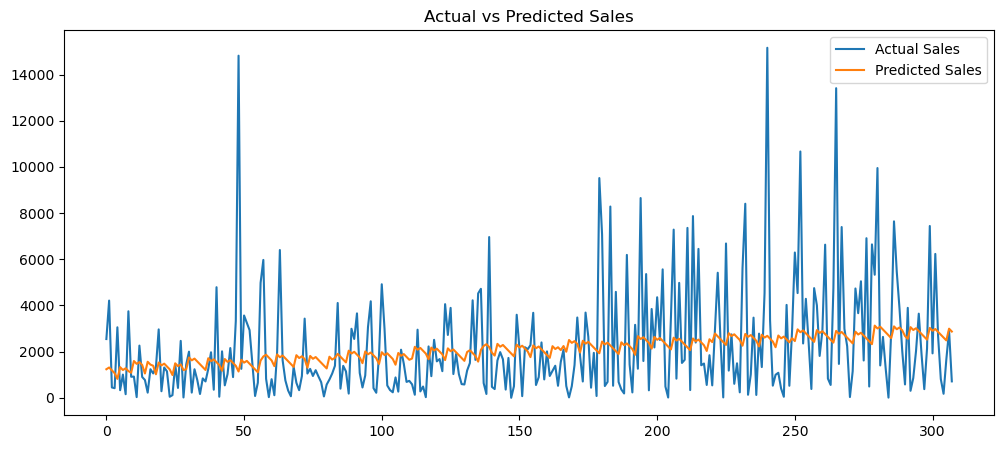

In [33]:
plt.figure(figsize=(12,5))
plt.plot(y_test.values, label="Actual Sales")
plt.plot(predictions, label="Predicted Sales")
plt.legend()
plt.title("Actual vs Predicted Sales")
plt.show()

In [34]:
# Create future dates
future_dates = pd.date_range(start=daily_sales['Order Date'].max(), periods=30)

future_df = pd.DataFrame({'Order Date': future_dates})

# Create features
future_df['Year'] = future_df['Order Date'].dt.year
future_df['Month'] = future_df['Order Date'].dt.month
future_df['Day'] = future_df['Order Date'].dt.day
future_df['DayOfWeek'] = future_df['Order Date'].dt.dayofweek
future_df['IsWeekend'] = future_df['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)

# Predict future sales
future_predictions = model.predict(future_df[['Year','Month','Day','DayOfWeek','IsWeekend']])

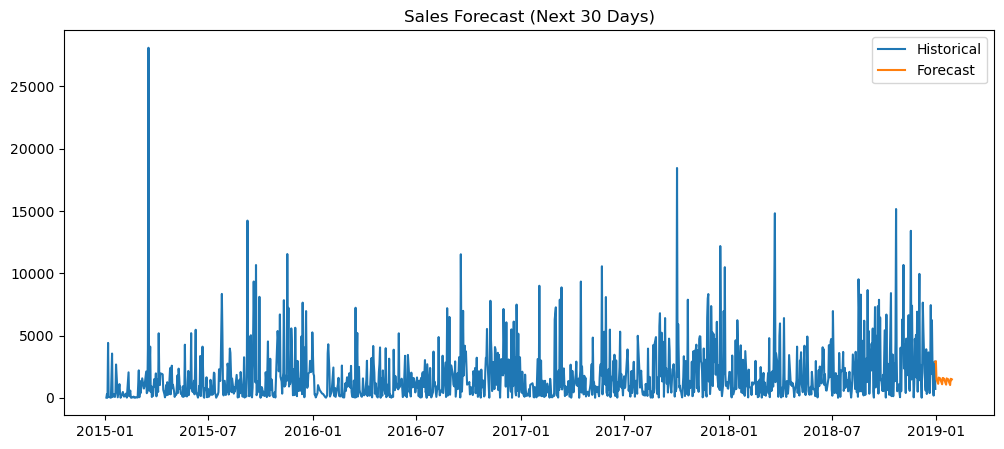

In [35]:
plt.figure(figsize=(12,5))

# Past data
plt.plot(daily_sales['Order Date'], daily_sales['Sales'], label="Historical")

# Future forecast
plt.plot(future_df['Order Date'], future_predictions, label="Forecast")

plt.legend()
plt.title("Sales Forecast (Next 30 Days)")
plt.show()

The model analyzes historical sales data and identifies patterns such as trends and seasonality. Using time-based features like month, day, and day of the week, it predicts future sales for the next 30 days.

The results show that sales follow consistent patterns over time, which can be used by businesses to improve planning and decision-making.

This forecast can help businesses:

Plan inventory more effectively
Avoid stock shortages or overstocking
Optimize staffing during peak periods
Improve financial planning and budgeting

Although a simple Linear Regression model was used, it provides a strong baseline for understanding demand patterns and can be improved further using more advanced models.

In [36]:
print(df.columns)

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')


In [37]:
daily_sales = daily_sales.dropna()

In [38]:
X.columns
future_df.columns

Index(['Order Date', 'Year', 'Month', 'Day', 'DayOfWeek', 'IsWeekend'], dtype='object')

In [41]:
daily_sales['Month_sin'] = np.sin(2 * np.pi * daily_sales['Month'] / 12)
daily_sales['Month_cos'] = np.cos(2 * np.pi * daily_sales['Month'] / 12)
y_test = y_test.reset_index(drop=True)

In [42]:
print(X.shape)
print(y.shape)
print(X.isnull().sum())

(1229, 5)
(1229,)
Year         0
Month        0
Day          0
DayOfWeek    0
IsWeekend    0
dtype: int64
